# EDA for events dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

events = pd.read_parquet('../data/events.parquet')

print('Shape:', events.shape)
print('\nColumns:')
print(events.columns.tolist())

events.head()

Shape: (19200, 21)

Columns:
['Date', 'Home_Team', 'Away_Team', 'Period', 'Clock', 'Home_Team_Skaters', 'Away_Team_Skaters', 'Home_Team_Goals', 'Away_Team_Goals', 'Team', 'Player_Id', 'Event', 'X_Coordinate', 'Y_Coordinate', 'Detail_1', 'Detail_2', 'Detail_3', 'Detail_4', 'Player_Id_2', 'X_Coordinate_2', 'Y_Coordinate_2']


,Date,Home_Team,Away_Team,Period,Clock,Home_Team_Skaters,Away_Team_Skaters,Home_Team_Goals,Away_Team_Goals,Team,...,Event,X_Coordinate,Y_Coordinate,Detail_1,Detail_2,Detail_3,Detail_4,Player_Id_2,X_Coordinate_2,Y_Coordinate_2
0,2025-10-11,Team D,Team A,1,20:00,5,5,0,0,Team D,...,Faceoff Win,0.0,0.5,Backhand,NaN,0,0,63,NaN,NaN
1,2025-10-11,Team D,Team A,1,19:57,5,5,0,0,Team D,...,Puck Recovery,-1.0,-3.5,NaN,NaN,0,0,NaN,NaN,NaN
2,2025-10-11,Team D,Team A,1,19:55,5,5,0,0,Team D,...,Zone Entry,25.0,-30.5,Carried,NaN,0,0,48,NaN,NaN
3,2025-10-11,Team D,Team A,1,19:54,5,5,0,0,Team D,...,Shot,42.0,-30.5,Wristshot,Blocked,1,0,NaN,NaN,NaN
4,2025-10-11,Team D,Team A,1,19:52,5,5,0,0,Team A,...,Puck Recovery,93.0,11.5,NaN,NaN,0,0,NaN,NaN,NaN


In [2]:
print('Dtypes:')
print(events.dtypes)

print('\nMissing values by column:')
print(events.isna().sum().sort_values(ascending=False))

print('\nNumeric summary:')
print(events.describe(include='number').T)

Dtypes:
Date                     str
Home_Team                str
Away_Team                str
Period                 int64
Clock                    str
Home_Team_Skaters      int64
Away_Team_Skaters      int64
Home_Team_Goals        int64
Away_Team_Goals        int64
Team                     str
Player_Id                str
Event                    str
X_Coordinate         float64
Y_Coordinate         float64
Detail_1                 str
Detail_2                 str
Detail_3               int64
Detail_4               int64
Player_Id_2              str
X_Coordinate_2       float64
Y_Coordinate_2       float64
dtype: object

Missing values by column:
Detail_2             18010
Y_Coordinate_2       10837
X_Coordinate_2       10837
Player_Id_2           8806
Detail_1              5991
Player_Id              312
Away_Team_Skaters        0
Home_Team_Goals          0
Away_Team_Goals          0
Team                     0
Home_Team                0
Event                    0
X_Coordinate      

In [3]:
cat_cols = ['Event', 'Team In Possession', 'Zone']
for col in cat_cols:
    if col in events.columns:
        print(f"\nTop values for {col}:")
        print(events[col].value_counts(dropna=False).head(15))

if {'Event', 'Team In Possession'}.issubset(events.columns):
    event_team = pd.crosstab(events['Event'], events['Team In Possession'])
    print('\nEvent x Team In Possession (top 15 events):')
    print(event_team.loc[event_team.sum(axis=1).sort_values(ascending=False).head(15).index])


Top values for Event:
Event
Play               6580
Puck Recovery      5360
Incomplete Play    1783
Zone Entry         1507
Dump In/Out        1476
Shot               1132
Takeaway            631
Faceoff Win         578
Penalty Taken        95
Goal                 58
Name: count, dtype: int64


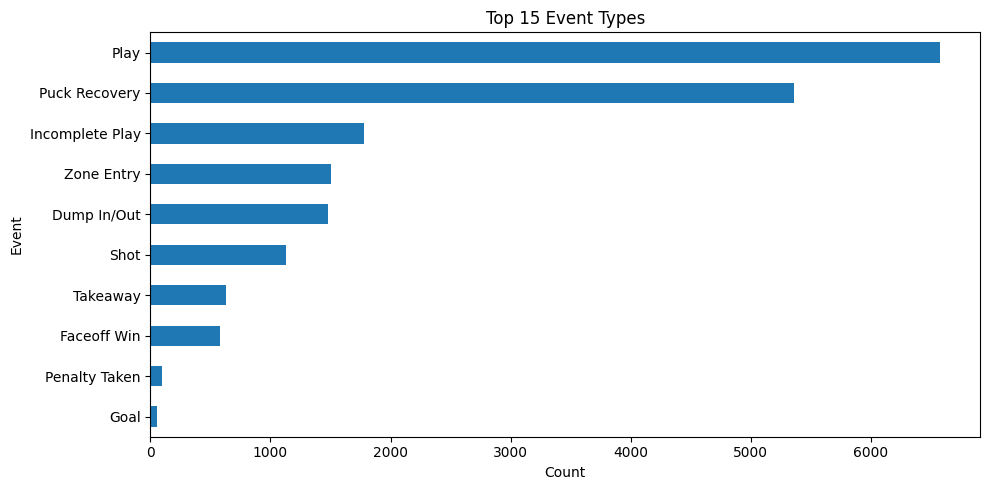

In [4]:
if 'Event' in events.columns:
    event_counts = events['Event'].value_counts().head(15)
    plt.figure(figsize=(10, 5))
    event_counts.sort_values().plot(kind='barh')
    plt.title('Top 15 Event Types')
    plt.xlabel('Count')
    plt.ylabel('Event')
    plt.tight_layout()
    plt.show()

if 'Game' in events.columns:
    per_game = events.groupby('Game').size().sort_values(ascending=False)
    print('\nRows per game:')
    print(per_game)
    
    plt.figure(figsize=(10, 4))
    per_game.plot(kind='bar')
    plt.title('Event Rows per Game')
    plt.xlabel('Game')
    plt.ylabel('Row count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()